In [6]:
import os
import cv2
import sklearn
import pandas as pd
import numpy as np
import seaborn as sn
import tensorflow as tf
from sklearn.svm import SVC
from tensorflow import keras
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.layers import BatchNormalization,MaxPooling2D,Conv2D,Flatten,Dense

In [2]:
path_of_dir=os.listdir('../brain tumor/Brain Tumor Data Set/')
classes_in_dir={'Healthy':0,'Brain Tumor':1}

classes_in_dir

{'Healthy': 0, 'Brain Tumor': 1}

In [ ]:
Y=[]
X=[]
for i in classes_in_dir:
    path='../brain tumor/Brain Tumor Data Set/'+i
    for j in os.listdir(path):
        pic=cv2.imread(path+'/'+j,1)
        pic=cv2.resize(pic,(200,200))
        X.append(pic)
        Y.append(classes_in_dir[i])


In [3]:
import random

# Augmentation function
def augment_image(img):
    aug_images = []

    # 1. Flip horizontally
    aug_images.append(cv2.flip(img, 1))

    # 2. Flip vertically
    aug_images.append(cv2.flip(img, 0))

    # 3. Rotation
    h, w = img.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, 15, 1.0)  # rotate 15 degrees
    aug_images.append(cv2.warpAffine(img, M, (w, h)))

    # 4. Random zoom (crop + resize back)
    zoom_factor = 0.8
    new_h, new_w = int(h * zoom_factor), int(w * zoom_factor)
    y1 = random.randint(0, h - new_h)
    x1 = random.randint(0, w - new_w)
    crop = img[y1:y1+new_h, x1:x1+new_w]
    aug_images.append(cv2.resize(crop, (w, h)))

    # 5. Brightness adjustment
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    hsv[:,:,2] = cv2.add(hsv[:,:,2], 30)  # increase brightness
    bright_img = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
    aug_images.append(bright_img)

    return aug_images


# Dataset paths
path_of_dir = os.listdir('../brain tumor/Brain Tumor Data Set/')
classes_in_dir = {'Healthy': 0, 'Brain Tumor': 1}

X = []
Y = []

# Load images + augment
for label_name in classes_in_dir:
    path = '../brain tumor/Brain Tumor Data Set/' + label_name
    for filename in os.listdir(path):
        img = cv2.imread(os.path.join(path, filename), 1)
        img = cv2.resize(img, (200, 200)).astype('uint8')

        # Append original
        X.append(img)
        Y.append(classes_in_dir[label_name])

        # Append augmented images
        for aug_img in augment_image(img):
            X.append(aug_img)
            Y.append(classes_in_dir[label_name])

print(f"Total images after augmentation: {len(X)}")


Total images after augmentation: 27600


In [7]:
x=np.array(X,dtype=np.uint8)
y=np.array(Y,dtype=np.uint8)
pd.Series(y).value_counts()

1    15078
0    12522
Name: count, dtype: int64

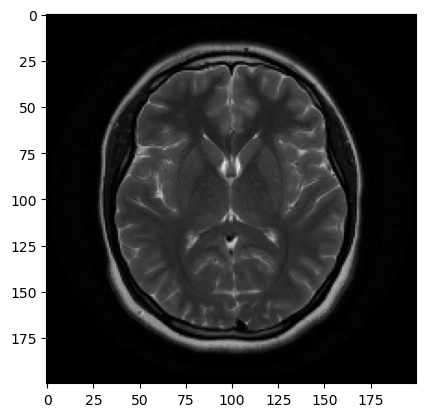

In [8]:
plt.imshow(x[1])


In [9]:
x.shape

(27600, 200, 200, 3)

In [11]:
x_3D=x.reshape(-1,200,200)
x_3D.shape

(82800, 200, 200)

In [12]:
x_3D.ndim

3

In [14]:
x_2D=x.reshape(len(x),-1)

In [15]:
x_2D.ndim

2

In [17]:
x_2D.shape

(27600, 120000)

In [18]:
x_2D.ndim

2

In [19]:
x_train3D,x_test3D,y_train3D,y_test3D=train_test_split(x,y,random_state=10,test_size=0.20)


In [20]:
x_train3D.shape

(22080, 200, 200, 3)

#CNN MODEL

In [21]:
cnn=tf.keras.models.Sequential([ keras.layers.Input(shape=(200,200,3)), 
Conv2D(filters=32, kernel_size=(5, 5), activation='relu'), # convolutional layer
BatchNormalization(),
MaxPooling2D(), # pooling layer

Conv2D(filters=64, kernel_size=(3, 3), activation='relu'), # convolutional layer
BatchNormalization(),
MaxPooling2D(), # pooling layer

Flatten(),
Dense(1,activation='sigmoid') # output layer

])
cnn.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 196, 196, 32)      2432      
                                                                 
 batch_normalization (BatchN  (None, 196, 196, 32)     128       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 98, 98, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 96, 96, 64)        18496     
                                                                 
 batch_normalization_1 (Batc  (None, 96, 96, 64)       256       
 hNormalization)                                                 
                                                        

In [22]:
cnn.compile(optimizer='adam',loss='binary_crossentropy', metrics=['accuracy'])

In [23]:
#train
cnn.fit(x_train3D,y_train3D, epochs=3, batch_size=32 ,validation_data=(x_test3D,y_test3D))

Epoch 1/3
690/690 [==============================] - 450s 650ms/step - loss: 1.8428 - accuracy: 0.8052 - val_loss: 1.2714 - val_accuracy: 0.8297
Epoch 2/3
690/690 [==============================] - 445s 645ms/step - loss: 0.8129 - accuracy: 0.8866 - val_loss: 1.3959 - val_accuracy: 0.8330
Epoch 3/3
690/690 [==============================] - 441s 639ms/step - loss: 0.5046 - accuracy: 0.9187 - val_loss: 0.7132 - val_accuracy: 0.8957


In [24]:
test_loss,test_acc=cnn.evaluate(x_test3D,y_test3D,verbose=2)

173/173 - 25s - loss: 0.7132 - accuracy: 0.8957 - 25s/epoch - 146ms/step


In [99]:
pred1=(cnn.predict(x_test3D)>0.5).astype('int').flatten()

29/29 [==============================] - 4s 141ms/step


In [100]:
accuracy_score(y_test3D,pred1)

0.925

In [101]:
conf_mat= confusion_matrix(y_test3D,pred1)
print(conf_mat)
print(classification_report(y_test3D,pred1))


[[388  28]
 [ 41 463]]
              precision    recall  f1-score   support

           0       0.90      0.93      0.92       416
           1       0.94      0.92      0.93       504

    accuracy                           0.93       920
   macro avg       0.92      0.93      0.92       920
weighted avg       0.93      0.93      0.93       920



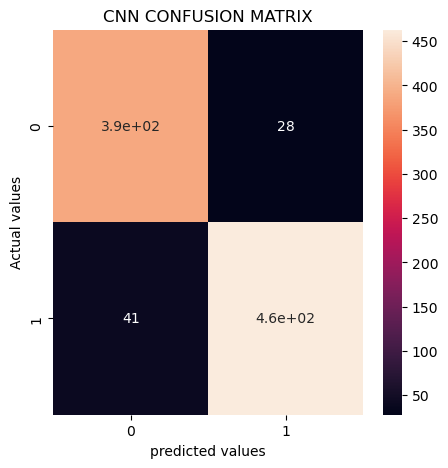

In [102]:
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("CNN CONFUSION MATRIX")
plt.show()

#Random forest

In [25]:
x_2D.shape

(4600, 120000)

In [26]:
x_train2D,x_test2D,y_train2D,y_test2D=train_test_split(x_2D,y,random_state=10,test_size=0.20)

In [27]:
x_train2D=x_train2D/255
x_test2D=x_test2D/255

In [28]:
x_train2D.shape

(3680, 120000)

In [29]:

rf=RandomForestClassifier()
rf.fit(x_train2D,y_train2D)

RandomForestClassifier()

In [30]:
pred2=rf.predict(x_test2D)

In [31]:
accuracy_score(y_test2D,pred2)

0.9684782608695652

In [32]:

conf_mat2=confusion_matrix(y_test2D,pred2)


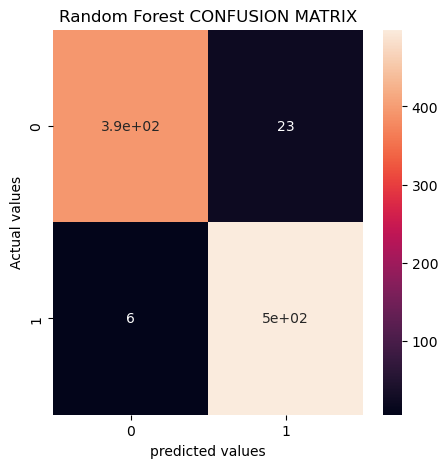

In [33]:
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat2,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("Random Forest CONFUSION MATRIX")
plt.show()

#SVM

In [34]:
# SVM

svm= SVC(kernel='linear',random_state=32)
svm.fit(x_train2D,y_train2D)

SVC(kernel='linear', random_state=32)

In [35]:
pred3=svm.predict(x_test2D)

In [36]:
accuracy_score(y_test2D,pred3)

0.9532608695652174

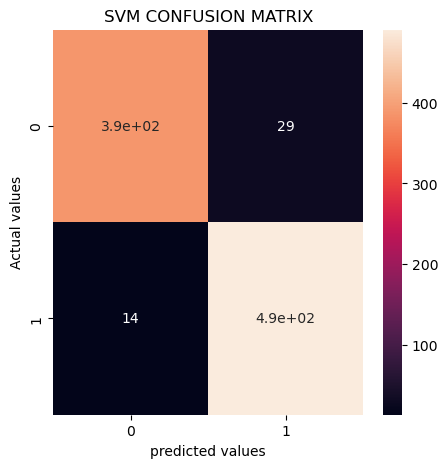

In [37]:
conf_mat3=confusion_matrix(y_test2D,pred3)
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat3,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("SVM CONFUSION MATRIX")
plt.show()

#KNN

In [38]:
knn=KNeighborsClassifier()
knn.fit(x_train2D,y_train2D)

KNeighborsClassifier()

In [39]:
pred4=knn.predict(x_test2D)

In [40]:
#evaluting the model
accuracy_score(y_test2D,pred4)

0.883695652173913

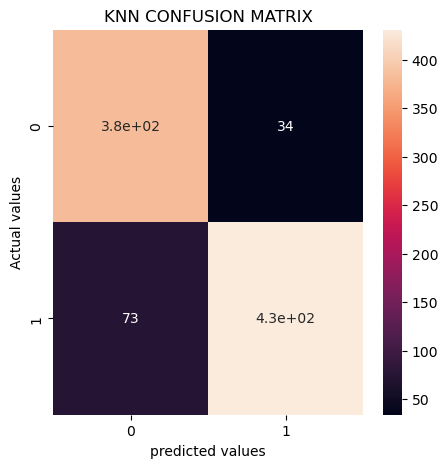

In [41]:
conf_mat4=confusion_matrix(y_test2D,pred4)
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat4,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("KNN CONFUSION MATRIX")
plt.show()

#Logistic Regression

In [42]:
LR = LogisticRegression(max_iter=1000, solver='lbfgs')
LR.fit(x_train2D, y_train2D)

LogisticRegression(max_iter=1000)

In [43]:
pred5 = LR.predict(x_test2D)

print("Accuracy:", accuracy_score(y_test2D, pred5))
print("\nClassification Report:\n", classification_report(y_test2D, pred5))

Accuracy: 0.9597826086956521

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.94      0.95       416
           1       0.95      0.97      0.96       504

    accuracy                           0.96       920
   macro avg       0.96      0.96      0.96       920
weighted avg       0.96      0.96      0.96       920



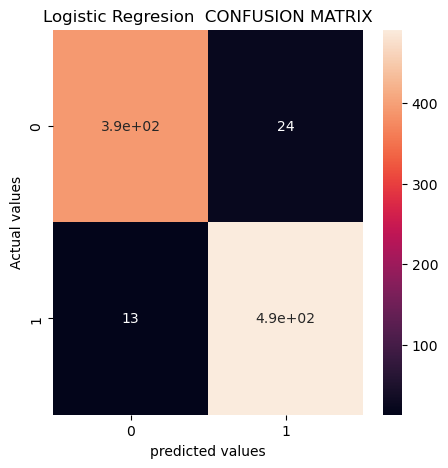

In [44]:
conf_mat5= confusion_matrix(y_test2D,pred5)
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat5,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("Logistic Regresion  CONFUSION MATRIX")
plt.show()

Text(0.5, 0, '1')

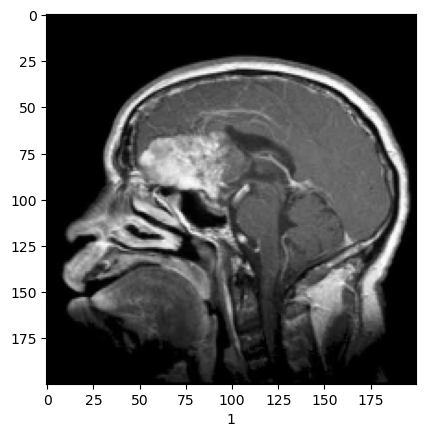

In [45]:
w=plt.imshow(x_test3D[50] ,cmap='gray')
plt.xlabel(y_test3D[50])

In [46]:
f=np.where(y_test3D != pred1)[0]

In [47]:
print(f)

[  1   5  13  26  28  30  55  82  86  87 124 160 162 196 208 217 220 233
 245 270 272 273 274 282 295 300 305 315 325 328 333 334 345 381 382 387
 389 411 413 415 424 472 488 504 505 515 533 541 557 574 589 615 618 630
 637 642 646 672 674 689 700 717 718 754 756 763 766 768 774 778 779 784
 792 801 816 829 834 838 855 859 861 864 912 913]


In [48]:
print("Y_test =",y_test2D[103])

Y_test = 1


In [49]:
print("CNN =",pred1[103])

CNN = 1


In [50]:
print("RF =",pred2[103])

RF = 1


In [51]:
print("SVM =",pred3[103])

SVM = 1


In [52]:
print("KNN =",pred4[103])

KNN = 1


In [53]:
print("LR =",pred5[103])

LR = 1


# ALL PREDICTED VALUES

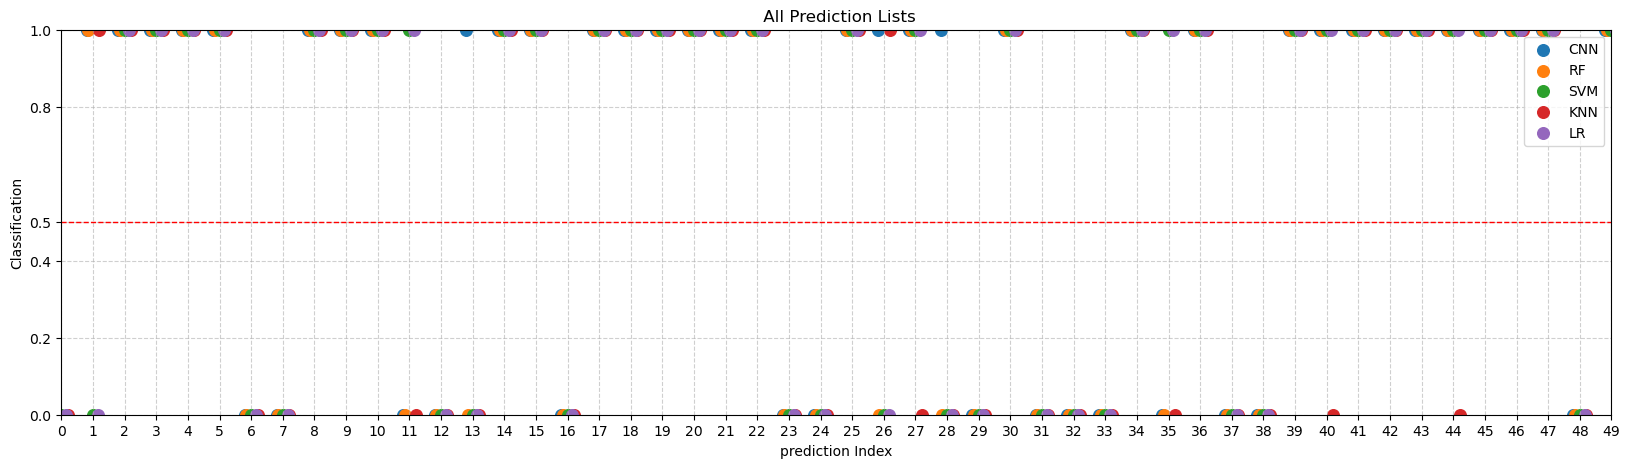

In [54]:
sze=np.arange(len(pred1))
plt.figure(figsize=(20,5))
plt.scatter(sze - 0.2, pred1, label='CNN', alpha=1, s=70)
plt.scatter(sze - 0.15, pred2, label='RF', alpha=1, s=70)
plt.scatter(sze, pred3, label='SVM', alpha=1, s=70)
plt.scatter(sze + 0.2, pred4, label='KNN', alpha=1, s=70)
plt.scatter(sze + 0.15 , pred5, label='LR', alpha=1, s=70)

plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1)

plt.ylim(0,1)
plt.xlim(0,10)
plt.xticks(range(0,50))
plt.yticks([0, 0.2,0.4,0.5,0.8,1])
plt.xlabel('prediction Index')
plt.ylabel('Classification')
plt.title(' All Prediction Lists')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()


In [36]:
import cv2
import random
import numpy as np



# -----------------------------
# Path to unseen image
img_path = r"D:\My Final Work\external_pic\12.jpg"

# Augmentation function (optional — only if you want to augment before predicting)
def augment_image(img):
    aug_images = []

    # Flip horizontally
    aug_images.append(cv2.flip(img, 1))

    # Flip vertically
    aug_images.append(cv2.flip(img, 0))

    # Rotation
    h, w = img.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, 15, 1.0)
    aug_images.append(cv2.warpAffine(img, M, (w, h)))

    # Random zoom
    zoom_factor = 0.8
    new_h, new_w = int(h * zoom_factor), int(w * zoom_factor)
    y1 = random.randint(0, h - new_h)
    x1 = random.randint(0, w - new_w)
    crop = img[y1:y1+new_h, x1:x1+new_w]
    aug_images.append(cv2.resize(crop, (w, h)))

    # Brightness adjustment
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    hsv[:, :, 2] = cv2.add(hsv[:, :, 2], 30)
    bright_img = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
    aug_images.append(bright_img)

    return aug_images

# -----------------------------
# Read and preprocess the image
img = cv2.imread(img_path)
img = cv2.resize(img, (200, 200))  # resize same as training size
img = img.astype('float32') / 255.0  # normalize

# Expand dimensions for model input
img_input = np.expand_dims(img, axis=0)

# Predict on the original image
prediction = cnn.predict(img_input)
print("Prediction for original image:", prediction)



1/1 [==============================] - 0s 68ms/step
Prediction for original image: [[0.98227817]]


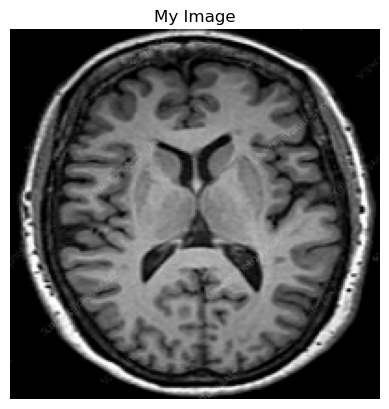

In [294]:
# Path to image
img_path = r"D:\My Final Work\external_pic\10.jpg"  # use raw string to avoid \n errors

# Read image
check_img = cv2.imread(img_path,1)
check_img=cv2.resize(check_img,(200,200))
# Show image
plt.imshow(check_img)
plt.axis('off')  # Hide axis numbers
plt.title("My Image")
plt.show()


In [295]:
outside_img =cv2.resize(check_img,(200,200))

In [296]:
outside_img.shape

(200, 200, 3)

In [297]:
cnnpred1=outside_img.reshape(1,200,200,3)
cnnpred=cnnpred1/255

In [298]:
cnnpred.shape

(1, 200, 200, 3)

In [299]:
cnnpred.ndim

4

In [ ]:
p1=(cnn.predict(cnnpred)>0.5).astype('int').flatten()

ValueError: in user code:

    File "c:\Users\shaha\anaconda3\envs\researchwork\lib\site-packages\keras\engine\training.py", line 2041, in predict_function  *
        return step_function(self, iterator)
    File "c:\Users\shaha\anaconda3\envs\researchwork\lib\site-packages\keras\engine\training.py", line 2027, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "c:\Users\shaha\anaconda3\envs\researchwork\lib\site-packages\keras\engine\training.py", line 2015, in run_step  **
        outputs = model.predict_step(data)
    File "c:\Users\shaha\anaconda3\envs\researchwork\lib\site-packages\keras\engine\training.py", line 1983, in predict_step
        return self(x, training=False)
    File "c:\Users\shaha\anaconda3\envs\researchwork\lib\site-packages\keras\utils\traceback_utils.py", line 70, in error_handler
        raise e.with_traceback(filtered_tb) from None
    File "c:\Users\shaha\anaconda3\envs\researchwork\lib\site-packages\keras\e

In [301]:
print(p1)

[1]


# below is for 2D arrays

In [302]:
p_2D=outside_img.reshape(1, -1)
p_2D.shape

(1, 120000)

In [303]:
p_2D.ndim

2

In [304]:
p_2D=p_2D/255

In [305]:
p2=rf.predict(p_2D)

In [306]:
print(p2)

[1]


In [307]:
p3=svm.predict(p_2D)

In [308]:
print(p3)

[1]


In [310]:
p4=LR.predict(p_2D)

In [311]:
print(p4)

[1]


In [312]:
p5=knn.predict(p_2D)

In [313]:
print(p5)

[0]


In [314]:
if(p1+p2+p3+p4+p5 >= 3):
    print("Tumor")
else:
    print("No Tumor")


Tumor
